# Notebook Bônus - Aula 06: Variational Autoencoders (VAEs) e Colorização de Paisagens

**Curso:** Redes Neurais Profundas (Deep Learning e Visão Computacional) - Instituto Infnet  
**Objetivo Prático:**
1. Compreender a diferença conceitual e matemática entre **Autoencoders Determinísticos** (estudados na Aula 06) e **Variational Autoencoders (VAEs)**.
2. Implementar o **Truque da Reparametrização (*Reparameterization Trick*)** e a função de perda combinada (**Reconstrução + Divergência KL**).
3. Construir uma arquitetura de **Convolutional VAE (ConvVAE)** no PyTorch para a tarefa de **Colorização de Imagens de Paisagem** (*Landscape Image Colorization*).
4. Explorar as propriedades generativas do espaço latente: **Interpolação Linear (Latent Space Walk)** e **Geração de Novas Paisagens a partir do Prior $\mathcal{N}(0, \mathbf{I})$**.

> 💡 **Dica para o Google Colab:** Este notebook é 100% compatível com o **Google Colab** (com aceleração de GPU T4/V100). O dataset é baixado automaticamente via `kagglehub`.

---
## 🧠 1. Revisão Teórica & Intuição Matemática do VAE

### 1.1 Do Autoencoder Clássico ao Variational Autoencoder

Na **Aula 06 principal**, vimos que um Autoencoder clássico comprime a imagem de entrada $X$ em um vetor latente determinístico $z = f(X)$. 
- **Limitação do AE Clássico:** O espaço latente $Z$ formado é descontínuo e irregular. Se amostramos um ponto aleatório de $Z$ que não caiu exatamente sobre os dados de treino, o Decoder costuma gerar imagens irreais e com artefatos.
- **A Solução do VAE:** Em vez de mapear $X$ para um **ponto fixo** $z$, o Encoder do VAE mapeia $X$ para os parâmetros de uma **distribuição de probabilidade**: a Média $\boldsymbol{\mu}(X)$ e a Variância $\boldsymbol{\sigma}^2(X)$.

$$\text{Encoder}(X) \longrightarrow \left( \boldsymbol{\mu}, \log(\boldsymbol{\sigma}^2) \right)$$

### 1.2 O Truque da Reparametrização (*Reparameterization Trick*)

Para passar a amostragem pelo Decoder, precisamos de um vetor latente $\mathbf{z} \sim \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\sigma}^2)$. No entanto, a amostragem aleatória pura inviabiliza o cálculo de derivadas (*backpropagation*).

O **Truque da Reparametrização** contorna isso isolando a estocasticidade em uma variável auxiliar $\boldsymbol{\epsilon} \sim \mathcal{N}(0, \mathbf{I})$:

$$\mathbf{z} = \boldsymbol{\mu} + \boldsymbol{\sigma} \odot \boldsymbol{\epsilon}$$

Desta forma, os gradientes em relação a $\boldsymbol{\mu}$ e $\boldsymbol{\sigma}$ podem fluir normalmente durante a etapa de *backward*!

### 1.3 A Função de Perda do VAE (Loss Function)

A Perda do VAE equilibra dois objetivos fundamentais:

$$\mathcal{L}_{VAE} = \mathcal{L}_{Reconstruction}(\hat{X}, X) + \beta \cdot \mathcal{D}_{KL}\left( q(\mathbf{z}|X) \parallel p(\mathbf{z}) \right)$$

1. **Perda de Reconstrução (MSE / BCE):** Força o Decoder a gerar uma imagem colorida o mais fiel possível ao alvo original.
2. **Divergência de Kullback-Leibler (KL Divergence):** Atua como um **regularizador**, forçando a distribuição latente aprendida $q(\mathbf{z}|X)$ a se aproximar de uma Gaussiana Padrão $p(\mathbf{z}) = \mathcal{N}(0, \mathbf{I})$.

Com a aproximação Gaussiana, a Divergência KL possui uma solução analítica fechada:

$$\mathcal{D}_{KL} = -\frac{1}{2} \sum_{j=1}^{d} \left( 1 + \log(\sigma_j^2) - \mu_j^2 - \exp(\log(\sigma_j^2)) \right)$$

## 2. Configuração do Ambiente e Importação de Bibliotecas

In [1]:
# Se estiver executando no Google Colab, descomente a linha abaixo para instalar o kagglehub:
# !pip install kagglehub

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import kagglehub

# Garantir reprodutibilidade dos experimentos
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo de processamento selecionado: {device}")

Dispositivo de processamento selecionado: cpu


## 3. Carregamento e Preparação do Dataset (*Landscape Image Colorization*)

Utilizaremos o dataset **Landscape Image Colorization** do Kaggle (`theblackmamba31/landscape-image-colorization`), composto por pares de imagens de paisagens em escala de cinza (*grayscale*) e coloridas (*RGB*).

In [2]:
# Download do dataset via kagglehub (compatível nativamente com Colab e Jupyter Local)
print("Baixando/Carregando dataset de paisagens do Kaggle...")
dataset_base_path = kagglehub.dataset_download('theblackmamba31/landscape-image-colorization')
print(f"Caminho do dataset local: {dataset_base_path}")

# Localizar subpastas de imagens
color_dir = os.path.join(dataset_base_path, 'landscape Images', 'color')
gray_dir = os.path.join(dataset_base_path, 'landscape Images', 'gray')

total_images = len(os.listdir(color_dir))
print(f"Total de imagens disponíveis no dataset: {total_images}")

Baixando/Carregando dataset de paisagens do Kaggle...


Caminho do dataset local: /home/allan/.cache/kagglehub/datasets/theblackmamba31/landscape-image-colorization/versions/4
Total de imagens disponíveis no dataset: 7129


### 3.1 Definição da Classe `Dataset` e `DataLoader` do PyTorch

In [3]:
class LandscapeColorizationDataset(Dataset):
    def __init__(self, color_dir, gray_dir, img_size=(64, 64), max_samples=None):
        self.color_dir = color_dir
        self.gray_dir = gray_dir
        
        filenames = sorted(os.listdir(color_dir))
        if max_samples is not None:
            filenames = filenames[:max_samples]
        self.filenames = filenames
        
        # Transformações para escala de cinza (1 canal) e colorida (3 canais)
        self.transform_gray = transforms.Compose([
            transforms.Resize(img_size),
            transforms.ToTensor()
        ])
        
        self.transform_color = transforms.Compose([
            transforms.Resize(img_size),
            transforms.ToTensor()
        ])
        
    def __len__(self):
        return len(self.filenames)
        
    def __getitem__(self, idx):
        fname = self.filenames[idx]
        color_path = os.path.join(self.color_dir, fname)
        gray_path = os.path.join(self.gray_dir, fname)
        
        color_img = Image.open(color_path).convert('RGB')
        gray_img = Image.open(gray_path).convert('L')
        
        gray_tensor = self.transform_gray(gray_img)    # [1, H, W]
        color_tensor = self.transform_color(color_img)  # [3, H, W]
        
        return gray_tensor, color_tensor

# Instanciar Datasets e DataLoaders
IMG_SIZE = (64, 64)
BATCH_SIZE = 64

# Utilizaremos 1200 amostras para treinamento ágil no notebook (no Colab pode expandir para max_samples=None)
dataset = LandscapeColorizationDataset(color_dir, gray_dir, img_size=IMG_SIZE, max_samples=1200)

# Divisão Train/Validation (80% / 20%)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Amostras de Treino: {len(train_dataset)} | Amostras de Validação: {len(val_dataset)}")

Amostras de Treino: 960 | Amostras de Validação: 240


### 3.2 Visualização Visual dos Pares de Entrada (Grayscale vs Ground Truth Colorido)

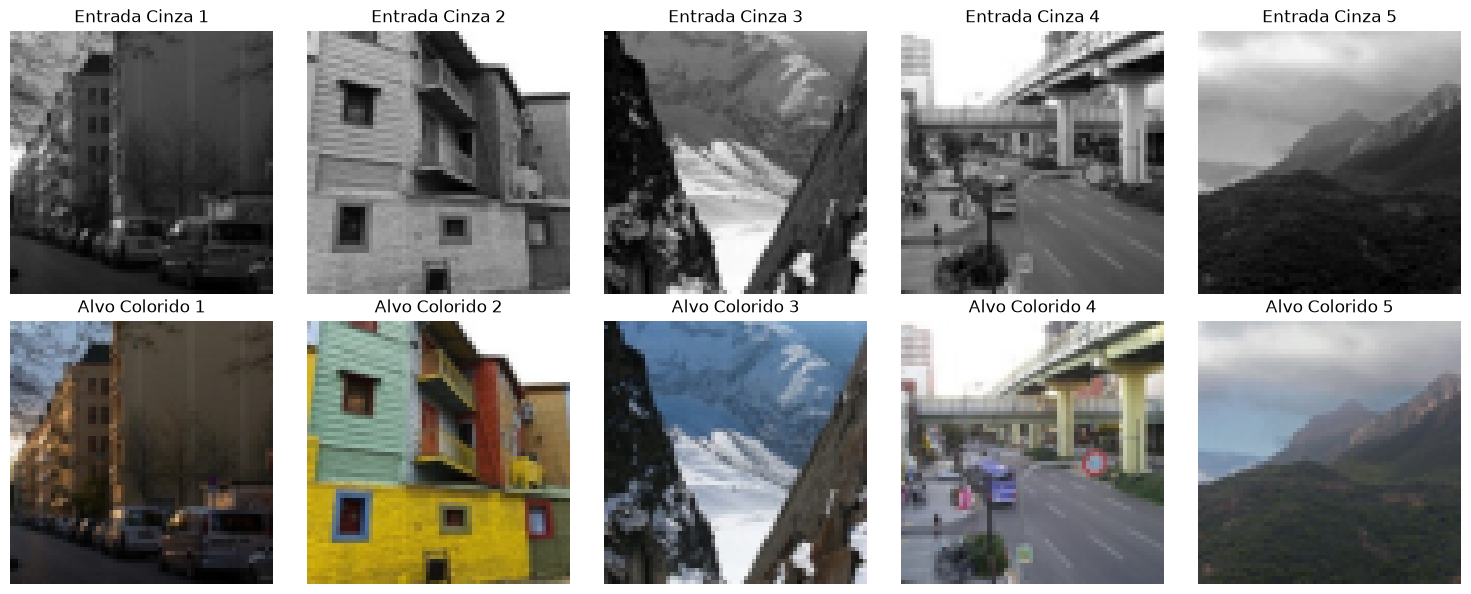

In [4]:
# Exibir 5 amostras do dataset
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i in range(5):
    gray_t, color_t = dataset[i]
    
    # Grayscale
    axes[0, i].imshow(gray_t.squeeze().numpy(), cmap='gray')
    axes[0, i].set_title(f"Entrada Cinza {i+1}")
    axes[0, i].axis('off')
    
    # RGB Ground Truth
    axes[1, i].imshow(color_t.permute(1, 2, 0).numpy())
    axes[1, i].set_title(f"Alvo Colorido {i+1}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## 4. Construção da Arquitetura Convolutional VAE (`ConvVAEColorizer`)

Projetaremos uma rede com a seguinte estrutura:
- **Encoder:** 4 camadas convolucionais com stride 2 para reduzir a resolução espacial de $64 \times 64$ para $4 \times 4$.
- **Projeções de Média e Variância:** Duas camadas `nn.Linear` que recebem os mapas de características comprimidos e produzem $\boldsymbol{\mu}$ e $\log(\boldsymbol{\sigma}^2)$ de dimensão `latent_dim` (ex: 128).
- **Reparametrização:** Função `reparameterize` que amostra $\mathbf{z} = \boldsymbol{\mu} + \boldsymbol{\sigma} \odot \boldsymbol{\epsilon}$.
- **Decoder:** Camada `nn.Linear` para descompactar $\mathbf{z}$, seguida de 4 camadas `nn.ConvTranspose2d` para restaurar a resolução para $3 \times 64 \times 64$ com ativador `nn.Sigmoid()` no final.

In [5]:
class ConvVAEColorizer(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim
        
        # 1. ENCODER CONVOLUCIONAL (Input: 1 x 64 x 64)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  # -> [32, 32, 32]
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # -> [64, 16, 16]
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),# -> [128, 8, 8]
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),# -> [256, 4, 4]
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True)
        )
        
        # Camadas Lineares para Mu e LogVar
        self.fc_mu = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, latent_dim)
        
        # 2. DECODER CONVOLUCIONAL
        self.decoder_input = nn.Linear(latent_dim, 256 * 4 * 4)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), # -> [128, 8, 8]
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # -> [64, 16, 16]
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # -> [32, 32, 32]
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),    # -> [3, 64, 64]
            nn.Sigmoid() # Garante saída no intervalo [0, 1]
        )
        
    def encode(self, x):
        h = self.encoder(x)
        h_flat = torch.flatten(h, start_dim=1)
        mu = self.fc_mu(h_flat)
        logvar = self.fc_logvar(h_flat)
        return mu, logvar
        
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
        
    def decode(self, z):
        h = self.decoder_input(z)
        h_unflat = h.view(-1, 256, 4, 4)
        recon_rgb = self.decoder(h_unflat)
        return recon_rgb
        
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_rgb = self.decode(z)
        return recon_rgb, mu, logvar

# Instanciar e testar dimensões do modelo
model = ConvVAEColorizer(latent_dim=128).to(device)
print(model)

ConvVAEColorizer(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2, inplace=True)
    (9): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (fc_mu): Linear(in_features=4096,

## 5. Função de Perda Combinada do VAE (Loss Function)

In [6]:
def vae_loss_function(recon_x, target_x, mu, logvar, beta=0.005):
    """
    Calcula a perda combinada do VAE:
    - Recon Loss: Erro de Reconstrução de Pixel (MSE)
    - KL Loss: Divergência de Kullback-Leibler em relação à Gaussiana N(0, I)
    - beta: Peso do fator de regularização (Beta-VAE)
    """
    # 1. Perda de Reconstrução (MSE entre a imagem reconstruída RGB e a real RGB)
    recon_loss = nn.functional.mse_loss(recon_x, target_x, reduction='sum') / recon_x.size(0)
    
    # 2. Divergência KL: -0.5 * sum(1 + log(sigma^2) - mu^2 - exp(log(sigma^2)))
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / recon_x.size(0)
    
    # Perda total com fator beta
    total_loss = recon_loss + beta * kl_loss
    
    return total_loss, recon_loss, kl_loss

## 6. Loop de Treinamento e Validação

In [7]:
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
epochs = 5
BETA = 0.005  # Fator beta equilibrado para fidelidade de cores e regularidade latente

history = {
    'train_loss': [], 'val_loss': [],
    'recon_loss': [], 'kl_loss': []
}

print("--- Iniciando Treinamento do ConvVAE Colorizer ---")

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    running_recon = 0.0
    running_kl = 0.0
    
    for gray_batch, color_batch in train_loader:
        gray_batch = gray_batch.to(device)
        color_batch = color_batch.to(device)
        
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(gray_batch)
        
        loss, r_loss, kl = vae_loss_function(recon_batch, color_batch, mu, logvar, beta=BETA)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * gray_batch.size(0)
        running_recon += r_loss.item() * gray_batch.size(0)
        running_kl += kl.item() * gray_batch.size(0)
        
    epoch_train_loss = running_loss / len(train_dataset)
    epoch_recon_loss = running_recon / len(train_dataset)
    epoch_kl_loss = running_kl / len(train_dataset)
    
    # Validação
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for gray_val, color_val in val_loader:
            gray_val = gray_val.to(device)
            color_val = color_val.to(device)
            
            val_recon, val_mu, val_logvar = model(gray_val)
            v_loss, _, _ = vae_loss_function(val_recon, color_val, val_mu, val_logvar, beta=BETA)
            val_running_loss += v_loss.item() * gray_val.size(0)
            
    epoch_val_loss = val_running_loss / len(val_dataset)
    
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['recon_loss'].append(epoch_recon_loss)
    history['kl_loss'].append(epoch_kl_loss)
    
    print(f"Época [{epoch:02d}/{epochs:02d}] | Train Loss: {epoch_train_loss:.2f} | Val Loss: {epoch_val_loss:.2f} | Recon MSE: {epoch_recon_loss:.2f} | KL: {epoch_kl_loss:.2f}")

--- Iniciando Treinamento do ConvVAE Colorizer ---


Época [01/05] | Train Loss: 726.50 | Val Loss: 625.06 | Recon MSE: 716.36 | KL: 2027.86


Época [02/05] | Train Loss: 466.88 | Val Loss: 407.25 | Recon MSE: 462.66 | KL: 843.18


Época [03/05] | Train Loss: 365.89 | Val Loss: 328.65 | Recon MSE: 360.93 | KL: 991.78


Época [04/05] | Train Loss: 329.96 | Val Loss: 306.28 | Recon MSE: 325.08 | KL: 975.20


Época [05/05] | Train Loss: 310.73 | Val Loss: 295.47 | Recon MSE: 306.21 | KL: 904.46


### 6.1 Gráficos das Curvas de Perda do Treinamento

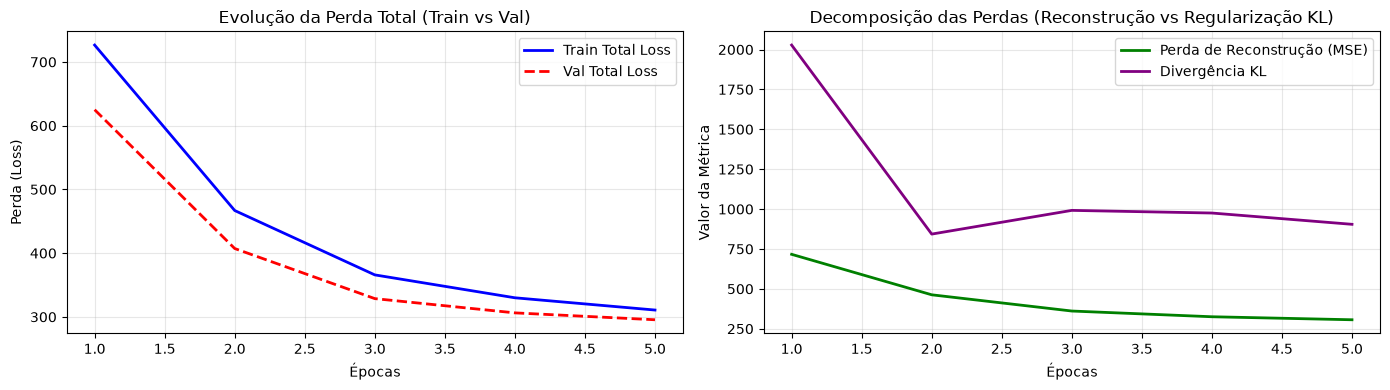

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Perda Total (Train vs Val)
ax1.plot(range(1, epochs+1), history['train_loss'], label='Train Total Loss', color='blue', linewidth=2)
ax1.plot(range(1, epochs+1), history['val_loss'], label='Val Total Loss', color='red', linestyle='--', linewidth=2)
ax1.set_title("Evolução da Perda Total (Train vs Val)")
ax1.set_xlabel("Épocas")
ax1.set_ylabel("Perda (Loss)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Decomposição: Reconstrução vs KL
ax2.plot(range(1, epochs+1), history['recon_loss'], label='Perda de Reconstrução (MSE)', color='green', linewidth=2)
ax2.plot(range(1, epochs+1), history['kl_loss'], label='Divergência KL', color='purple', linewidth=2)
ax2.set_title("Decomposição das Perdas (Reconstrução vs Regularização KL)")
ax2.set_xlabel("Épocas")
ax2.set_ylabel("Valor da Métrica")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Avaliação Prática e Experimentos Generativos

### Experimento 1: Colorização de Imagens de Teste (Inferência)
Vamos avaliar como o ConvVAE colorizou imagens do conjunto de validação nunca vistas durante o treino.

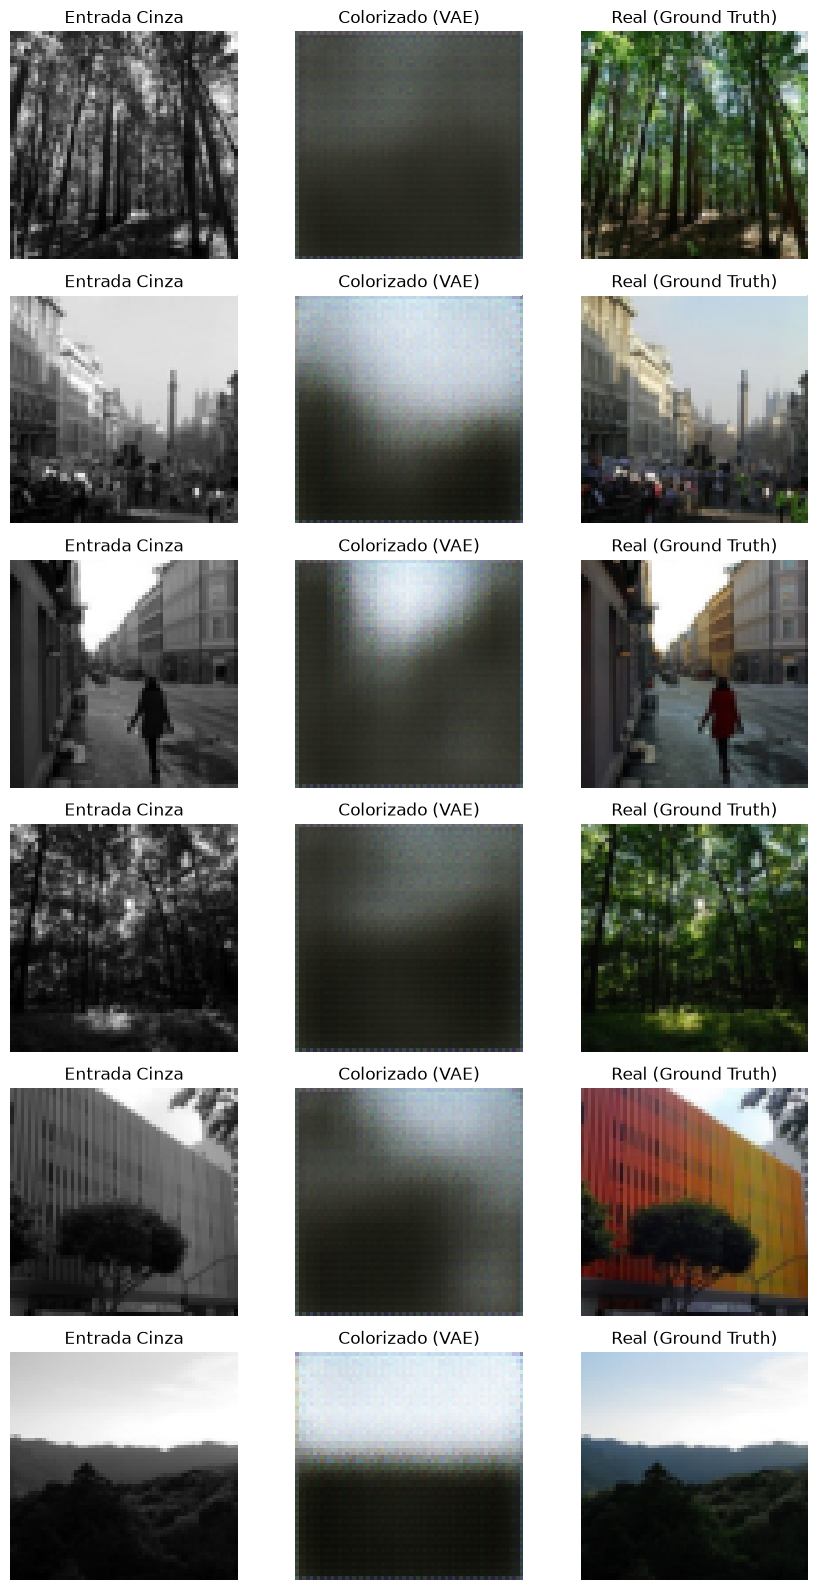

In [9]:
model.eval()
with torch.no_grad():
    gray_samples, color_samples = next(iter(val_loader))
    gray_samples = gray_samples.to(device)
    recon_samples, _, _ = model(gray_samples)
    
    gray_samples = gray_samples.cpu()
    color_samples = color_samples.cpu()
    recon_samples = recon_samples.cpu()

# Plotar 6 comparações [Entrada Grayscale | Previsão VAE | Ground Truth Colorido]
fig, axes = plt.subplots(6, 3, figsize=(9, 16))

for i in range(6):
    # 1. Grayscale Input
    axes[i, 0].imshow(gray_samples[i].squeeze().numpy(), cmap='gray')
    axes[i, 0].set_title("Entrada Cinza")
    axes[i, 0].axis('off')
    
    # 2. VAE Predicted RGB
    axes[i, 1].imshow(recon_samples[i].permute(1, 2, 0).numpy())
    axes[i, 1].set_title("Colorizado (VAE)")
    axes[i, 1].axis('off')
    
    # 3. Ground Truth RGB
    axes[i, 2].imshow(color_samples[i].permute(1, 2, 0).numpy())
    axes[i, 2].set_title("Real (Ground Truth)")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

### Experimento 2: Interpolação no Espaço Latente (*Latent Space Walk*)

Como o VAE foi treinado com a Divergência KL, o espaço latente $Z$ é **contínuo e suave**. Se pegarmos o vetor latente $\mathbf{z}_1$ de uma paisagem A e o vetor $\mathbf{z}_2$ de uma paisagem B, podemos interpolar linearmente entre eles:

$$\mathbf{z}(\alpha) = (1 - \alpha) \mathbf{z}_1 + \alpha \mathbf{z}_2, \quad \alpha \in [0, 1]$$

Ao passar cada $\mathbf{z}(\alpha)$ pelo Decoder, observamos uma transição suave e gradual de cores e formas!

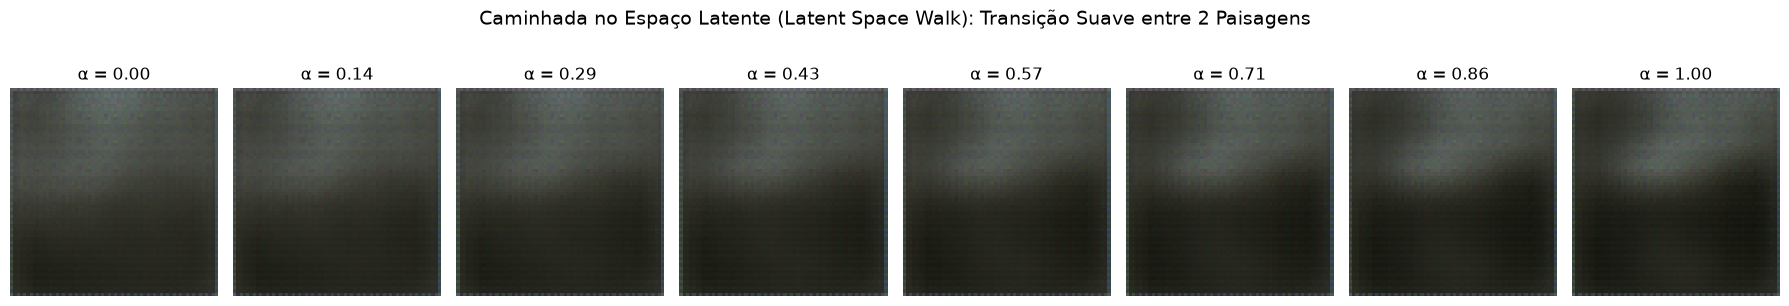

In [10]:
model.eval()
with torch.no_grad():
    # Selecionar duas imagens distintas da validação
    img1 = gray_samples[0:1].to(device)
    img2 = gray_samples[3:4].to(device)
    
    # Obter vetores de média mu
    mu1, _ = model.encode(img1)
    mu2, _ = model.encode(img2)
    
    # Gerar 8 passos de interpolação alpha entre 0 e 1
    alphas = np.linspace(0, 1, 8)
    interpolated_imgs = []
    
    for alpha in alphas:
        z_interp = (1 - alpha) * mu1 + alpha * mu2
        recon_interp = model.decode(z_interp)
        interpolated_imgs.append(recon_interp.squeeze().cpu().permute(1, 2, 0).numpy())

# Exibir a caminhada no espaço latente
fig, axes = plt.subplots(1, 8, figsize=(18, 3))
for idx, (img, alpha) in enumerate(zip(interpolated_imgs, alphas)):
    axes[idx].imshow(np.clip(img, 0, 1))
    axes[idx].set_title(f"α = {alpha:.2f}")
    axes[idx].axis('off')

plt.suptitle("Caminhada no Espaço Latente (Latent Space Walk): Transição Suave entre 2 Paisagens", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

### Experimento 3: Geração Purely Generativa de Paisagens a partir do Prior $\mathcal{N}(0, \mathbf{I})$

Diferente dos Autoencoders clássicos, **podemos amostrar vetores totalmente aleatórios da distribuição Gaussiana Padrão** $\mathbf{z} \sim \mathcal{N}(0, \mathbf{I})$ sem precisar de NENHUMA imagem de entrada, e pedir para o Decoder sintetizar cores de paisagem!

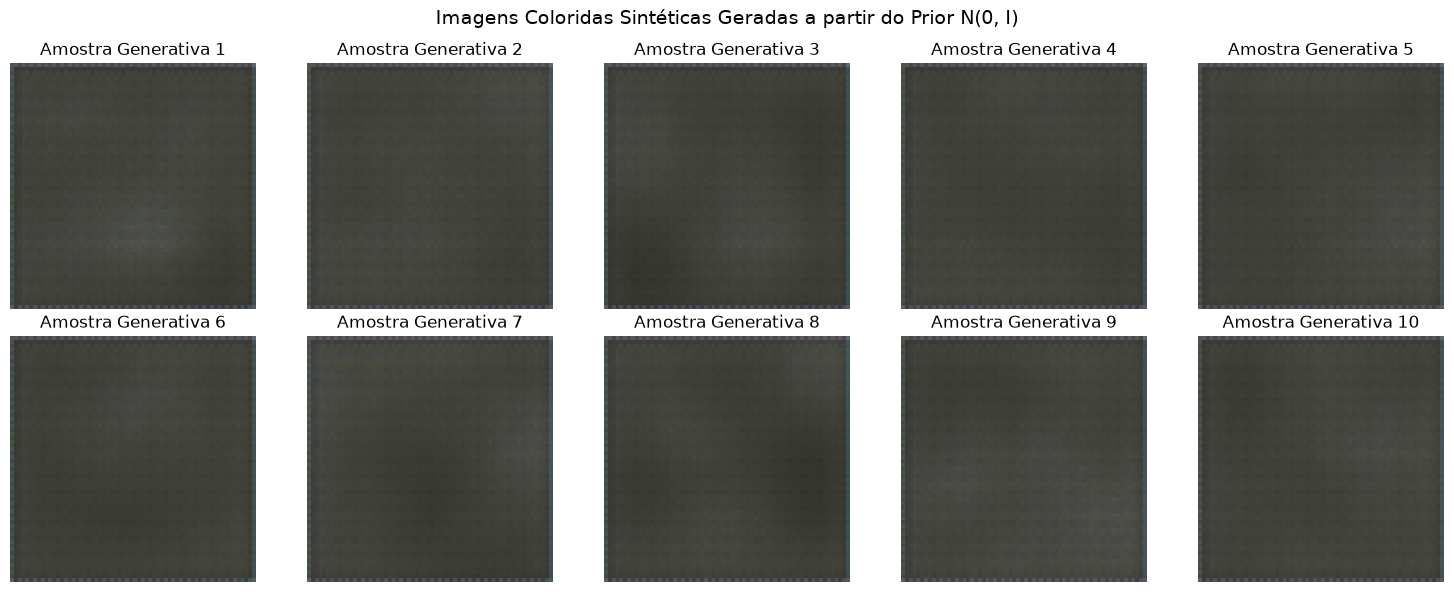

In [11]:
model.eval()
with torch.no_grad():
    # Amostrar 10 vetores latentes aleatórios N(0, I)
    random_z = torch.randn(10, 128).to(device)
    generated_colors = model.decode(random_z).cpu()

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for idx, ax in enumerate(axes.flat):
    img = generated_colors[idx].permute(1, 2, 0).numpy()
    ax.imshow(np.clip(img, 0, 1))
    ax.set_title(f"Amostra Generativa {idx+1}")
    ax.axis('off')

plt.suptitle("Imagens Coloridas Sintéticas Geradas a partir do Prior N(0, I)", fontsize=14)
plt.tight_layout()
plt.show()

---
## 📝 8. Exercícios de Fixação & Desafios Práticos

1. **Impacto do Fator $\beta$ (Beta-VAE):**
   - Altere o hiperparâmetro `BETA` na função de perda para `BETA = 0.5` (valor alto) e depois para `BETA = 0.0001` (valor muito baixo).
   - *Pergunta:* O que acontece com a nitidez e riqueza das cores quando $\beta$ é muito alto? O que acontece com a capacidade generativa do modelo quando $\beta \to 0$?

2. **Espaço de Cor CIELAB (L*a*b*):**
   - Em vez de usar RGB, pesquise como converter imagens para o espaço de cor **CIELAB** usando a biblioteca `scikit-image` ou `torchvision`.
   - *Desafio:* Treine o VAE usando o canal `L` como entrada e prevendo apenas os canais `a` e `b` ($2 \times H \times W$).

3. **Dimensão do Espaço Latente:**
   - Teste `latent_dim = 16` e `latent_dim = 512`.
   - Observe a diferença na Perda de Reconstrução versus a qualidade da interpolação no espaço latente.